In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

df = pd.read_csv(r"C:\Users\HP\Documents\ML Project\data\application_train.csv")
print(f"Original shape: {df.shape}")
print(f"Default rate: {df['TARGET'].mean()*100:.2f}%")

Original shape: (307511, 122)
Default rate: 8.07%


## Feature Engineering Plan

From the EDA we know:
1. **28 columns have >40% missing data** — mostly building/property area features → drop them
2. **EXT_SOURCE_1/2/3** are the most predictive features but EXT_SOURCE_1 has 56% missing → impute carefully
3. **DAYS_BIRTH and DAYS_EMPLOYED** are negative integers → convert to positive years
4. **Class imbalance** (8.07% default) → handle during modelling with class_weight='balanced'

Engineering steps today:
- Step 1: Drop high-missing columns (>40% missing)
- Step 2: Create domain-driven features from credit risk knowledge
- Step 3: Handle remaining missing values
- Step 4: Encode categorical variables
- Step 5: Save clean dataset to data/processed/

In [13]:
# Calculate missing percentage for every column
missing_pct = (df.isnull().sum() / len(df) * 100)

# Identify columns with more than 40% missing
cols_to_drop = [
    col for col in missing_pct[missing_pct > 40].index
    if col != 'EXT_SOURCE_1'
]

# Drop them
df = df.drop(columns=cols_to_drop)
print(f"\nShape after dropping high-missing columns: {df.shape}")


Shape after dropping high-missing columns: (307511, 74)


In [21]:
# --- Credit Risk Domain Features ---

# 1. Age in years (DAYS_BIRTH is negative — days before application)
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).round(1)

# 2. Employment length in years
# DAYS_EMPLOYED has an anomaly — value 365243 means unemployed
# Replace anomaly with NaN first
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['EMPLOYMENT_YEARS'] = (-df['DAYS_EMPLOYED'] / 365).round(1)

# 3. Credit-to-income ratio — how large is the loan relative to income?
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

# 4. Annuity-to-income ratio — monthly debt burden relative to income
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# 5. Credit term — how many years to repay?
df['CREDIT_TERM_YEARS'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']

# 6. Income per family member — household financial pressure
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].replace(0, 1)

# 7. EXT_SOURCE mean — average of all three bureau scores
# These are the most predictive features — combine them
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1)
df['EXT_SOURCE_MIN'] = df[ext_cols].min(axis=1)

# 8. Age-employment ratio — what proportion of adult life spent employed?
df['EMPLOYMENT_AGE_RATIO'] = df['EMPLOYMENT_YEARS'] / df['AGE_YEARS']

print("New features created:")
new_features = ['AGE_YEARS','EMPLOYMENT_YEARS','CREDIT_INCOME_RATIO',
                'ANNUITY_INCOME_RATIO','CREDIT_TERM_YEARS','INCOME_PER_PERSON',
                'EXT_SOURCE_MEAN','EXT_SOURCE_MIN','EMPLOYMENT_AGE_RATIO']
print(df[new_features].describe().round(3))

New features created:
        AGE_YEARS  EMPLOYMENT_YEARS  CREDIT_INCOME_RATIO  \
count 307511.0000       252137.0000          307511.0000   
mean      43.9370            6.5320               3.9580   
std       11.9560            6.4070               2.6900   
min       20.5000            0.0000               0.0050   
25%       34.0000            2.1000               2.0190   
50%       43.2000            4.5000               3.2650   
75%       53.9000            8.7000               5.1600   
max       69.1000           49.1000              84.7370   

       ANNUITY_INCOME_RATIO  CREDIT_TERM_YEARS  INCOME_PER_PERSON  \
count           307499.0000        307499.0000        307509.0000   
mean                 0.1810             0.0540         93105.8800   
std                  0.0950             0.0220        101373.3630   
min                  0.0000             0.0220          2812.5000   
25%                  0.1150             0.0370         47250.0000   
50%                  0.

## Business Observation: Why These Features Matter

From 5 years in credit risk, the single biggest predictor of default 
is not income level — it is the **ratio of debt obligations to income**.

A borrower earning ₦500,000/month taking a ₦1,000,000 loan is in a 
fundamentally different risk category than a borrower earning ₦100,000/month 
taking the same loan.

The raw AMT_CREDIT column cannot tell you this. CREDIT_INCOME_RATIO can.

Similarly, EXT_SOURCE scores (external credit bureau data) are the closest 
equivalent to a formal credit score in this dataset. Where they are available, 
they dominate all other features. Where they are missing, we use the mean 
of available scores — preserving signal without discarding the record.

This is why domain knowledge matters more than algorithmic sophistication 
at the feature engineering stage.

In [24]:
# Check remaining missing values
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
print(f"Columns still with missing values: {len(remaining_missing)}")
print(remaining_missing.head(20))

Columns still with missing values: 27
EXT_SOURCE_1                  173378
OCCUPATION_TYPE                96391
EXT_SOURCE_3                   60965
EMPLOYMENT_AGE_RATIO           55374
DAYS_EMPLOYED                  55374
EMPLOYMENT_YEARS               55374
AMT_REQ_CREDIT_BUREAU_HOUR     41519
AMT_REQ_CREDIT_BUREAU_YEAR     41519
AMT_REQ_CREDIT_BUREAU_QRT      41519
AMT_REQ_CREDIT_BUREAU_MON      41519
AMT_REQ_CREDIT_BUREAU_WEEK     41519
AMT_REQ_CREDIT_BUREAU_DAY      41519
NAME_TYPE_SUITE                 1292
OBS_60_CNT_SOCIAL_CIRCLE        1021
DEF_60_CNT_SOCIAL_CIRCLE        1021
DEF_30_CNT_SOCIAL_CIRCLE        1021
OBS_30_CNT_SOCIAL_CIRCLE        1021
EXT_SOURCE_2                     660
AMT_GOODS_PRICE                  278
EXT_SOURCE_MIN                   172
dtype: int64


In [26]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

# Impute numeric columns with median
# Median is more robust than mean for skewed financial data
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Impute categorical columns with mode
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Verify no missing values remain
print(f"\nMissing values remaining: {df.isnull().sum().sum()}")
print("Expected: 0")

Numeric columns: 71
Categorical columns: 12

Missing values remaining: 0
Expected: 0


In [28]:
# Check categorical columns and their unique values
print("Categorical columns:")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values")

Categorical columns:
  NAME_CONTRACT_TYPE: 2 unique values
  CODE_GENDER: 3 unique values
  FLAG_OWN_CAR: 2 unique values
  FLAG_OWN_REALTY: 2 unique values
  NAME_TYPE_SUITE: 7 unique values
  NAME_INCOME_TYPE: 8 unique values
  NAME_EDUCATION_TYPE: 5 unique values
  NAME_FAMILY_STATUS: 6 unique values
  NAME_HOUSING_TYPE: 6 unique values
  OCCUPATION_TYPE: 18 unique values
  WEEKDAY_APPR_PROCESS_START: 7 unique values
  ORGANIZATION_TYPE: 58 unique values


In [43]:
# Label encode binary categoricals (2 unique values)
# One-hot encode low-cardinality categoricals (3-7 unique values)
# Drop high-cardinality categoricals (too many unique values)

le = LabelEncoder()

binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
low_card_cols = [col for col in cat_cols if 3 <= df[col].nunique() <= 7]
high_card_cols = [col for col in cat_cols if df[col].nunique() > 7]

print(f"Binary columns (label encode): {len(binary_cols)}")
print(binary_cols)
print(f"\nLow cardinality (one-hot encode): {len(low_card_cols)}")
print(low_card_cols)
print(f"\nHigh cardinality (drop): {len(high_card_cols)}")
print(high_card_cols)

# Label encode binary columns
for col in binary_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# One-hot encode low cardinality columns
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

# Drop high cardinality columns
df = df.drop(columns=high_card_cols)

print(f"\nFinal shape after encoding: {df.shape}")

Binary columns (label encode): 3
['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

Low cardinality (one-hot encode): 6
['CODE_GENDER', 'NAME_TYPE_SUITE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START']

High cardinality (drop): 3
['NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']

Final shape after encoding: (307511, 102)


In [ ]:
import os
os.makedirs(r'C:\Users\HP\Documents\ML Project/data/processed', exist_ok=True)

df.to_csv(r'C:\Users\HP\Documents\ML Project/data/processed/application_train_clean.csv', index=False)

print(f"Clean dataset saved.")
print(f"Final shape: {df.shape}")
print(f"Target rate preserved: {df['TARGET'].mean()*100:.2f}%")
print(f"\nFeature summary:")
print(f"  Total features: {df.shape[1] - 1}")
print(f"  New engineered features: 9")
print(f"  Original features retained: {df.shape[1] - 10}")

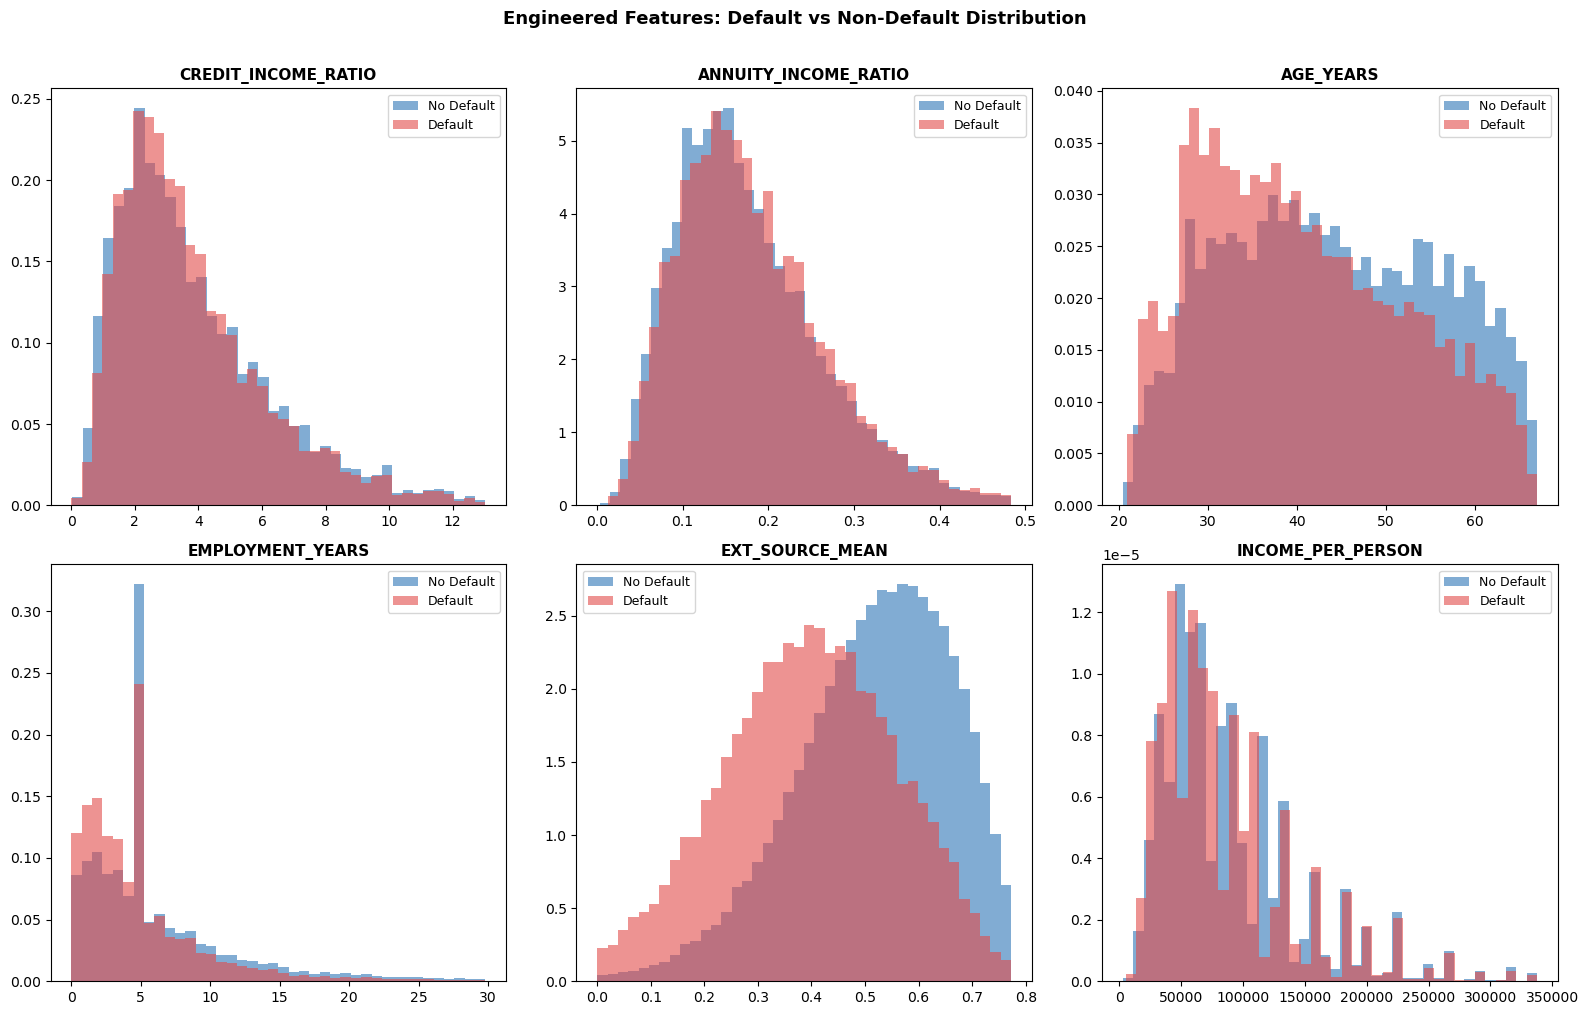

Chart saved to reports/


In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features_to_plot = [
    'CREDIT_INCOME_RATIO', 
    'ANNUITY_INCOME_RATIO',
    'AGE_YEARS', 
    'EMPLOYMENT_YEARS',
    'EXT_SOURCE_MEAN',
    'INCOME_PER_PERSON'
]

for i, feature in enumerate(features_to_plot):
    cap = df[feature].quantile(0.99)
    plot_data = df[df[feature] <= cap]
    
    axes[i].hist(plot_data[plot_data['TARGET']==0][feature], 
                 bins=40, alpha=0.6, color='#2E75B6', 
                 label='No Default', density=True)
    axes[i].hist(plot_data[plot_data['TARGET']==1][feature], 
                 bins=40, alpha=0.6, color='#E24B4A', 
                 label='Default', density=True)
    axes[i].set_title(feature, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('Engineered Features: Default vs Non-Default Distribution', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(r"C:\Users\HP\Documents\ML Project\loan-default-prediction-\reports/engineered_features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/")

In [41]:
print("=" * 55)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 55)
print(f"Original columns:        122")
print(f"After dropping >40% NA:  ~73")
print(f"Engineered features added: 9")
print(f"After encoding:          {df.shape[1]-1} features")
print(f"Records:                 {df.shape[0]:,}")
print(f"Missing values:          0")
print(f"Target rate:             {df['TARGET'].mean()*100:.2f}%")
print(f"\nSaved to: data/processed/application_train_clean.csv")
print(f"Next: 03_baseline_model.ipynb — Logistic Regression")
print("=" * 55)

FEATURE ENGINEERING SUMMARY
Original columns:        122
After dropping >40% NA:  ~73
Engineered features added: 9
After encoding:          82 features
Records:                 307,511
Missing values:          0
Target rate:             8.07%

Saved to: data/processed/application_train_clean.csv
Next: 03_baseline_model.ipynb — Logistic Regression
